# Debugging Notebook for functions

In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
from encoding import *
from processing import *
from decoding import *
from visualize import *
from mesh import *
from main import *
import numpy as np
import matplotlib.pyplot as plt

# Loading data from mnist set
Functions in encoding.py

7
Number of '7' in this set: 1028, number of '1' in this set: 1135


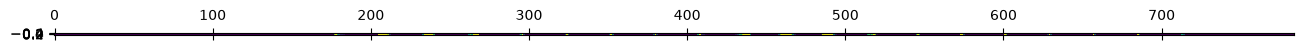

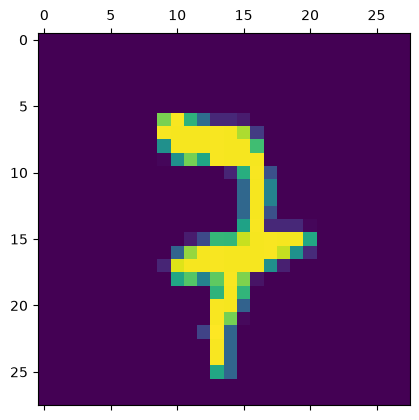

In [167]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m_side = 28 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X, Y = get_data(values, mode, number, m_side, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels
#Example of the first entry
plt.matshow(np.real(E_X[:,0]).reshape(1, -1), ) #reshaping it just for plotting with plt.matshow
plt.matshow(np.real(E_X[:,0]).reshape(m,m))
print(Y[0])

print("Number of '7' in this set: " + str(np.sum(Y == 7))+", number of '1' in this set: " + str(np.sum(Y == 1)))


# Initializing MZI-Mesh
Functions in mesh.py
(No parameter initialization yet)

Number of layers in the setup: 4
MZIs along the layers in the setup: [2, 1, 2, 1]
Total number of (trainable) MZIs in the setup: 6


<Axes: title={'center': 'N=4, 4 Layer, 6 MZIs'}, xlabel='Layer', ylabel='Channel'>

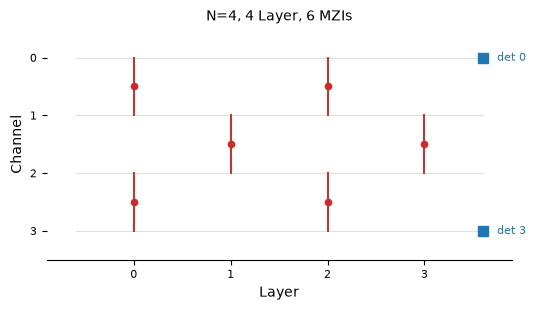

In [52]:
N=4 #Number of channels
L=4 #Number of layers
test_plan = plan_rectangular(N, L) #other plans are plan_redundant and plan_triangular
test_mesh = MZIMesh(N, test_plan) #Object containing the geometry of the MZI-Mesh

#Each mesh object carries its properties:
n_layers = test_mesh.n_layers
n_slots = test_mesh.slot_counts
n_mzis = test_mesh.n_mzis
print(f"Number of layers in the setup: {n_layers}") #layers of setup
print(f"MZIs along the layers in the setup: {n_slots}") #distribution of MZIs along the layers
print(f"Total number of (trainable) MZIs in the setup: {n_mzis}") #number of (trainable MZIs in this setup)


plot_mesh(test_mesh, color_by=None, detectors=[0, 3], label_step=None) #function of visualize.py to show the geometry (and detectors)


# Initializing Mesh parameters
Functions in mesh.py, here just init_random, also init_haar already coded (later used)

Phis: [array([2.486788  , 2.23570602]), array([1.91974875]), array([0.78668074, 2.99688041]), array([2.4614445])]
Thetas: [array([6.15291569, 0.23968592]), array([6.14337335]), array([5.59689753, 5.09633843]), array([0.53538818])]


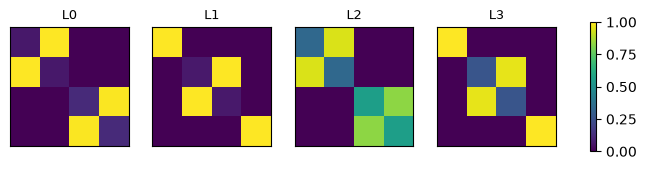

In [53]:
phis, thetas = test_mesh.init_random()
print(f"Phis: {phis}")
print(f"Thetas: {thetas}")

layers = test_mesh.layer_matrices(thetas, phis)   #building layers (transfer matrices) out of the parameters
fig, _ = plot_layers(layers, mode="Abs")


# Propagation

[[-0.00235357-0.00945984j  0.05615949+0.02308336j -0.00650188-0.00817509j
  ...  0.00919564-0.01205516j  0.03570935+0.01686381j
   0.04846815+0.0239164j ]
 [ 0.01679514+0.0296378j  -0.0007064 -0.02901452j  0.01387123+0.03134803j
  ...  0.0024725 -0.01031715j -0.00368508-0.01554283j
  -0.00495961-0.02566937j]
 [ 0.0156583 -0.00713105j -0.01775511-0.02066385j  0.03266381-0.00490053j
  ... -0.00051927-0.0222478j  -0.0095905 -0.00917983j
  -0.01767405-0.01280597j]
 ...
 [ 0.02763519-0.02255615j  0.01349024-0.00360842j  0.03252902-0.0417068j
  ...  0.00073702+0.04352892j  0.04949515-0.03534126j
   0.00339956+0.00464821j]
 [-0.03301071-0.01618255j -0.02686136-0.00762385j -0.02144585-0.02792982j
  ...  0.01283696+0.01662991j -0.0419482 -0.04012709j
  -0.02649191+0.00149911j]
 [ 0.01501676-0.01503862j  0.02290034-0.00633448j  0.03938989+0.01630269j
  ... -0.0043701 +0.01515529j  0.03360765-0.01173738j
   0.01829562-0.01049263j]]
(100, 110)
[[[ 0.        +0.j          0.        +0.j
    0.     

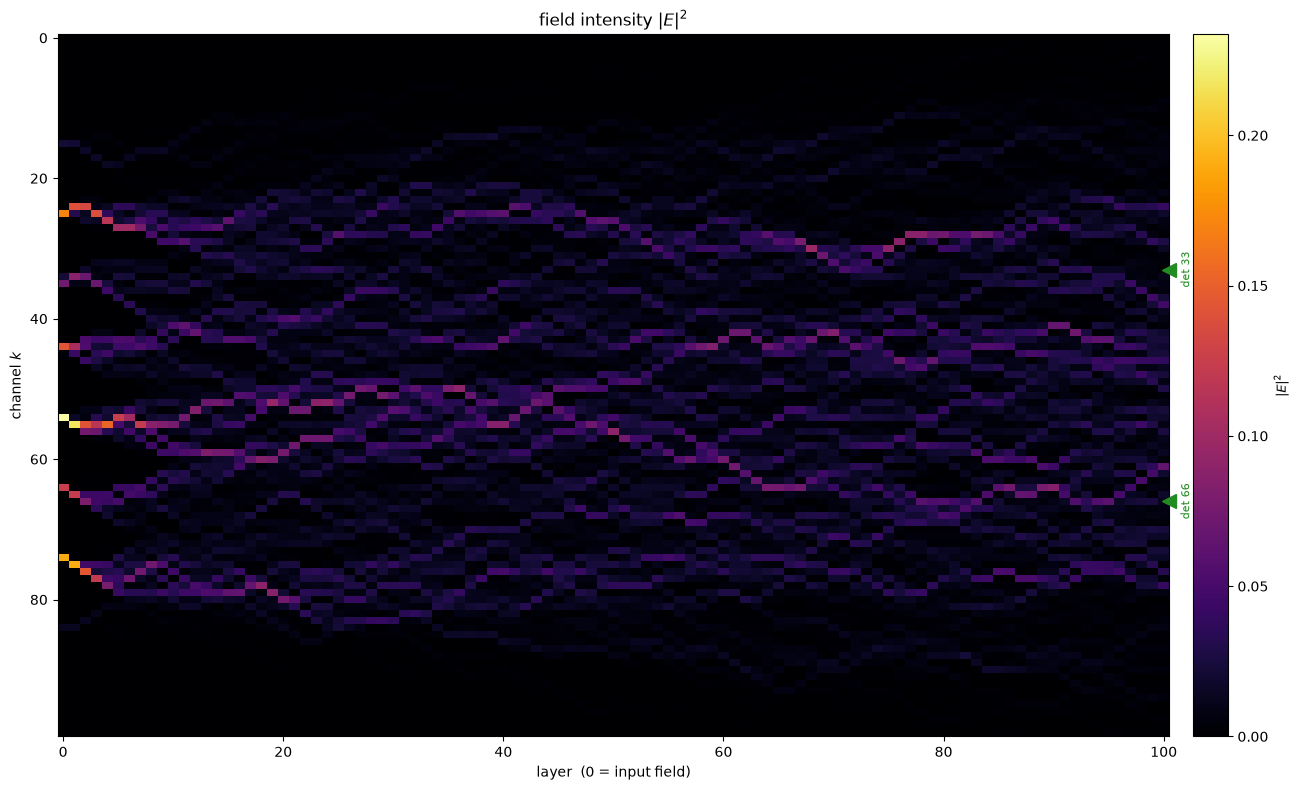

In [78]:
N=100 #number of channels (number of pixels in mnist image)
prop_mesh = MZIMesh(N, plan_rectangular(N, N)) #creating mesh object
thetas, phis = prop_mesh.init_random() #initializing random weights

layers = prop_mesh.layer_matrices(thetas, phis)   #build transfer matrices (layers) from parameters

E_out  = forward(E_X, layers)         #propagation that gives end result directly
print(E_out)                          #format: [channels, batches]
print(np.shape(E_out))

E_hist = forward_history(E_X, layers) #propagation that gives all E-fields for every layer
print(E_hist)                         #format: [layers, channels, batches]
I = np.abs(E_hist[:,:,2])**2
fig, _ = plot_intensity_map(I, detectors=[33,66])

c:\Users\tim\OneDrive - Friedrich-Schiller-Universität Jena\Universität\Jena\2. Semester\Optical Machine Learning\MANTIS\visualize.py:57: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  Heatmap  = Mittelwert ueber alle Samples.


(<Figure size 1509x800 with 3 Axes>,
 (<Axes: title={'center': 'mean field intensity $|E|^2$'}, xlabel='layer  (0 = input field)', ylabel='channel $k$'>,
  <Axes: xlabel='norm. $|E|^2$'>))

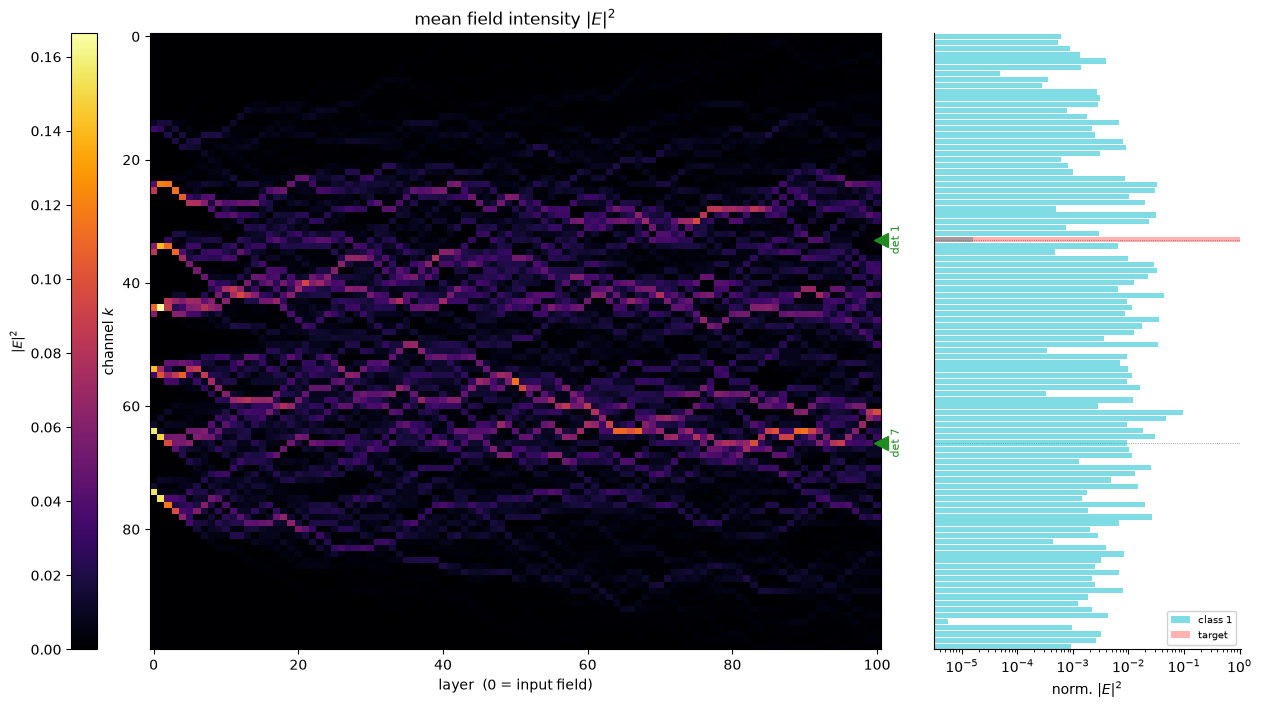

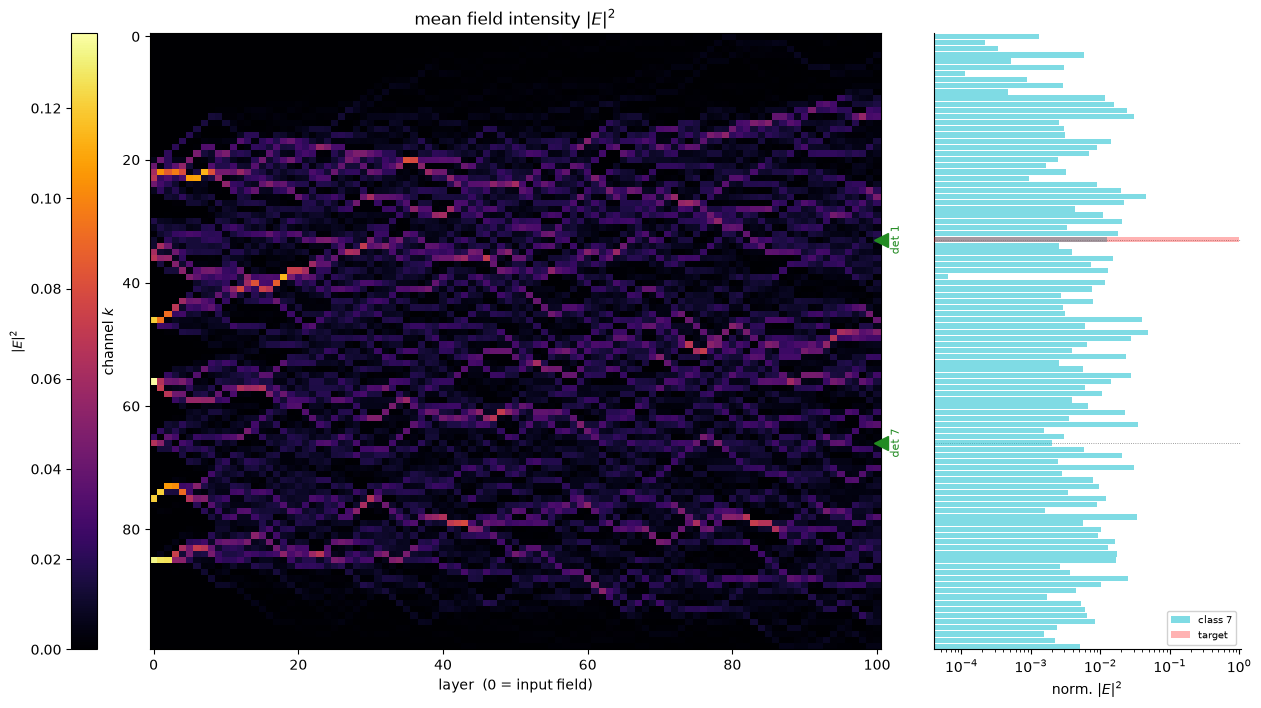

In [79]:
plot_intensity_map_with_histogram(np.abs(E_hist[:,:,40])**2, det1=33, det7=66, Y=Y[40])
plot_intensity_map_with_histogram(np.abs(E_hist[:,:,64])**2, det1=33, det7=66, Y=Y[64])

(110,)
[0.98481939 0.97800019 0.9998667  0.99061499 0.99597994 0.99922156
 0.98109058 0.99742525 0.99853387 0.99769012 0.99020879 0.99704155
 0.97632327 0.99511784 0.99764915 0.99729841 0.99939034 0.99783649
 0.97292981 0.96753131 0.99610394 0.99584996 0.99937487 0.99153555
 0.99805719 0.99288044 0.99959828 0.99999953 0.99623455 0.9818216
 0.99711454 0.99092245 0.99335357 0.99338909 0.99956429 0.99193473
 0.9930481  0.99826893 0.99637274 0.99648401 1.00005538 0.9953165
 0.98016879 0.99259504 0.99444347 0.99632828 0.99671132 0.98318252
 0.99822807 0.9968995  0.99341991 0.9975752  0.99612373 0.99849724
 0.99752504 0.97965236 0.99825128 0.99369468 0.97344704 0.99867289
 0.98345002 0.99845424 0.97615393 0.99636129 0.9961537  0.98800827
 0.99153277 0.9829907  0.98605894 0.99553731 0.98284268 0.99584004
 0.99591349 0.99449536 0.99608445 0.99762054 0.99454982 0.99532935
 0.9950538  0.99309112 0.98179144 0.98650215 0.99909798 0.99043081
 0.95588934 0.99481315 0.99301935 0.99463708 0.97465073 0

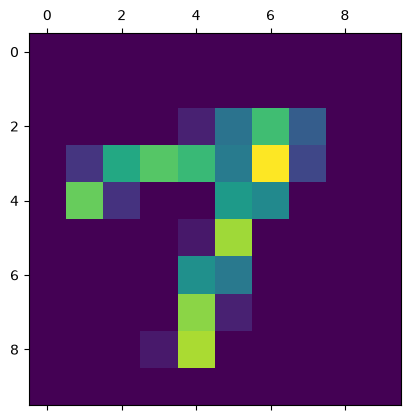

In [97]:
loss=loss_function(E_hist, Y, 33, 66)
print(np.shape(loss[1]))
print(loss[1])
print(np.argmin(loss[1]))
print(np.argmax(loss[1]))
print(E_X[64])
plt.matshow(np.real(E_X[:,45].T).reshape(10,10))
print(np.sum(np.abs(E_X[:,2])**2))

In [57]:
a = np.zeros((3,3))
print(a[:,1])

b=np.ones(3)
c=a[:,1].copy
print(type(a[:,1]))
print(type(b))
print(np.diff(c[:],b))

[0. 0. 0.]
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


TypeError: 'builtin_function_or_method' object is not subscriptable

# Linear regression
with vs. without normalized energy

In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_predict, accuracy = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy)

[[1134    1]
 [  16 1012]]
0.9921405455386038


In [ ]:
print(np.shape(E_X_Train))
mask7 = Y_Train==7
mask1 = Y_Train==1
print(np.mean(np.abs(E_X_Train[:,mask7])**2, axis=0))
print(np.mean(np.abs(E_X_Train[:,mask1])**2, axis=0))


(100, 13007)
[0.01 0.01 0.01 ... 0.01 0.01 0.01]
[0.01 0.01 0.01 ... 0.01 0.01 0.01]


In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = True #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

theta, y_predict, accuracy = linear_regression(E_X_Train.T, Y_Train, E_X_Test.T, Y_Test)
print(accuracy)

[[1133    2]
 [  14 1014]]
0.9926028663892742


## Plotting intensity-differences between 7 and 1

In [ ]:
values = np.array([1,7]) #figures you want from the mnist dataset
mode = "Testing" #Selects if you want the test-set ("Testing") or the training-set ("Training")
number = None #Sets number of samples you want to get in total
m = 10 #side length (pixel) of mnist image after downsampling
theta = 1 #mysterious hyper parameter for amplitude scaling
norm_energy = False #Bool for if energy of encoded image should be normalized or not
seed = None #Random seed to control random choice of number -pictures out of the available ones, 
            #seed = None leads to random results for each iteration

E_X_Train, Y_Train = get_data(values, "Training", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels

E_X_Test, Y_Test = get_data(values, "Testing", number, m, theta, norm_energy, seed) #E_X are the flattened arrays of the encoded mnist images (complex valued), 
                                                                  #Y are the referring labels


(100, 13007)


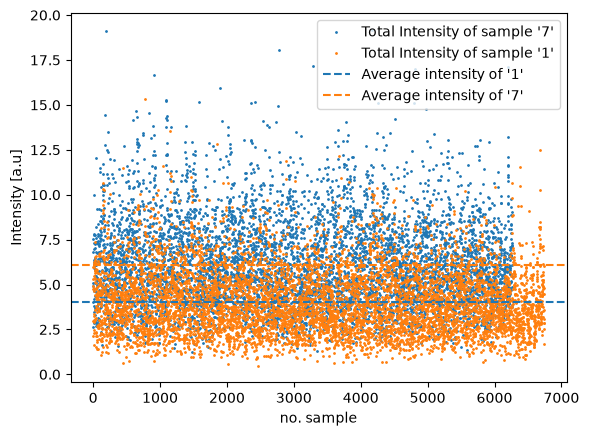

In [ ]:
print(np.shape(E_X_Train))
mask7 = Y_Train==7
mask1 = Y_Train==1

sumIntensity7 = np.sum(np.abs(E_X_Train[:,mask7])**2, axis=0)
sumIntensity1 = np.sum(np.abs(E_X_Train[:,mask1])**2, axis=0)
avgIntensity7 = np.mean(sumIntensity7)
avgIntensity1 = np.mean(sumIntensity1)
plt.plot(sumIntensity7, color="tab:blue", label="Total Intensity of sample '7'", linewidth=0.0, marker="o", markersize=1)
plt.plot(sumIntensity1, color="tab:orange", label="Total Intensity of sample '1'", linewidth=0.0, marker="o", markersize=1)
plt.axhline(y=avgIntensity1, color="tab:blue", linestyle="--", label="Average intensity of '1'")
plt.axhline(y=avgIntensity7, color="tab:orange", linestyle="--", label="Average intensity of '7'")
plt.ylabel("Intensity [a.u]")
plt.xlabel("no. sample")
plt.legend()

# O